# Training Clinical and Comorbidity models

## Loading libraries

In [1]:
# Training Model OB1+OB2 data
# Import modules
import pandas as pd
from math import sqrt
import os
import random
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.svm import SVC
from sklearn.feature_selection import SelectFromModel
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, BayesianRidge
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
import sklearn.impute
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
import seaborn as sb
import statistics
import seaborn as sn
from sklearn.model_selection import StratifiedKFold
from collections import Counter
import sklearn.ensemble
from statistics import mean
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import f1_score
from sklearn.model_selection import cross_val_score
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from sklearn import metrics
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import KFold, StratifiedKFold, RepeatedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import random
import pandas as pd
import scipy.stats as stats
import os

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss

from sklearn.model_selection import GridSearchCV, KFold,RepeatedKFold
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.feature_selection import SelectKBest, f_classif, RFE

from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, KFold,RepeatedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# from sksurv.linear_model import CoxnetSurvivalAnalysis
# from sksurv.metrics import concordance_index_censored
# from sksurv.util import Surv
#@title Set up the environment
import numpy as np
import sys
import pandas as pd
from collections import Counter, defaultdict
from IPython.display import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense,Flatten,Input,Lambda,GlobalAveragePooling2D,Dropout,Conv2D,BatchNormalization,MaxPooling2D,Input,Activation
from tensorflow.keras.models import Model,Sequential
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img,img_to_array,array_to_img
from tensorflow.keras.optimizers import Adam,RMSprop,SGD
from tensorflow.keras.applications.densenet import DenseNet169, preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping,ReduceLROnPlateau
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.decomposition import FastICA, PCA
from sklearn.metrics import accuracy_score, f1_score
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.models import load_model
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import os
import math
from tensorflow.keras.regularizers import l2
import json
import pickle
import random

/Users/sarahgalante/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
import numpy

print(numpy.__version__)


1.25.2


In [3]:
#@title Set up the environment
import numpy as np
import sys
import pandas as pd
from collections import Counter, defaultdict
from IPython.display import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense,Flatten,Input,Lambda,GlobalAveragePooling2D,Dropout,Conv2D,BatchNormalization,MaxPooling2D,Input,Activation
from tensorflow.keras.models import Model,Sequential
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img,img_to_array,array_to_img
from tensorflow.keras.optimizers import Adam,RMSprop,SGD
from tensorflow.keras.applications.densenet import DenseNet169, preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping,ReduceLROnPlateau
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.decomposition import FastICA, PCA
from sklearn.metrics import accuracy_score, f1_score
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.models import load_model
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import os
import math
from tensorflow.keras.regularizers import l2
import json
import pickle
import random

## ML MODELS
Functions of ML models to be used to train the models

#### ADABOOST

In [77]:
def ada_classif(xtrain, ytrain, xtest, ytest):
   param_grid = {
        'n_estimators': [50, 100, 500],
        'learning_rate': [0.001, 0.01,0.1],
        'estimator__max_depth': [2, 3, 5],
        'estimator__min_samples_split': [2, 5, 10],
        'estimator__min_samples_leaf': [1, 2, 4],
        'estimator__max_features': [None, 'sqrt', 'log2']
   }
    
   base_tree = DecisionTreeClassifier(random_state=42)
   mdl = AdaBoostClassifier(estimator=base_tree, random_state=42)

   grid_search = GridSearchCV(mdl, param_grid, scoring='f1', cv=5, verbose=0, n_jobs=-1)
   grid_search.fit(xtrain, ytrain)
   best_model = grid_search.best_estimator_

   ypred = best_model.predict(xtest)
   prob = best_model.predict_proba(xtest)[:, 1]
   bal_acc, f1, sensitivity, specificity, auc = compute_metrics_classif(ytest, ypred, prob)
    
   tn, fp, fn, tp = confusion_matrix(ytest, ypred).ravel()

   return bal_acc, f1, sensitivity, specificity, auc, tp, tn, fp, fn, best_model


#### RF

In [78]:
def rf_classif(xtrain, ytrain, xtest=None, ytest=None):
    param_grid = {
        'n_estimators': [50, 100, 200],
        'criterion': ['entropy', 'gini'],
        'max_depth': [1, 2, 3, 4],
        'min_samples_split': [2, 4, 6, 8, 10],
        'min_samples_leaf': [2, 4, 6, 8, 10]
    }
    mdl = RandomForestClassifier(random_state=42)
    grid_search = GridSearchCV(mdl, param_grid, scoring='f1', cv=5, verbose=0, n_jobs=-1)
    grid_search.fit(xtrain, ytrain)
    best_model = grid_search.best_estimator_

    if xtest is not None and ytest is not None:
        ypred = best_model.predict(xtest)
        prob = best_model.predict_proba(xtest)[:, 1]
        bal_acc, f1, sensitivity, specificity, auc = compute_metrics_classif(ytest, ypred, prob)
        
        tn, fp, fn, tp = confusion_matrix(ytest, ypred).ravel()
        return bal_acc, f1, sensitivity, specificity, auc, tp, tn, fp, fn, best_model
    else:
        # Valutazione in-sample sul training stesso
        ypred_train = best_model.predict(xtrain)
        prob_train = best_model.predict_proba(xtrain)[:, 1]
        bal_acc, f1, sensitivity, specificity, auc = compute_metrics_classif(ytrain, ypred_train, prob_train)
        
        print("In-sample Training Metrics:")
        print(f"Balanced Accuracy: {bal_acc:.4f}")
        print(f"F1 Score: {f1:.4f}")
        print(f"Sensitivity: {sensitivity:.4f}")
        print(f"Specificity: {specificity:.4f}")
        print(f"AUC: {auc:.4f}")


#### XGB

In [79]:
def xgb_classif(xtrain, ytrain, xtest, ytest):
    param_grid = {
        'n_estimators': [100, 300],
        'learning_rate': [0.05, 0.1],
        'min_child_weight': [1, 5],
        'gamma': [0.5, 1, 2],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0],
        'max_depth': [3, 5]
    }
    mdl = XGBClassifier(random_state=42, eval_metric='logloss')  # Aggiunto per warning
    grid_search = GridSearchCV(mdl, param_grid, scoring='f1', cv=5, verbose=0, n_jobs=-1)
    grid_search.fit(xtrain, ytrain)
    best_model = grid_search.best_estimator_

    ypred = best_model.predict(xtest)
    prob = best_model.predict_proba(xtest)[:, 1]
    bal_acc, f1, sensitivity, specificity, auc = compute_metrics_classif(ytest, ypred, prob)
    
    tn, fp, fn, tp = confusion_matrix(ytest, ypred).ravel()

    return bal_acc, f1, sensitivity, specificity, auc, tp, tn, fp, fn, best_model


#### LR

In [80]:
def lr_classif(xtrain, ytrain, xtest, ytest):
    param_grid = {"C": [1e-2, 0.1, 1, 10],
                  "solver": ['liblinear', 'lbfgs', 'newton-cg'],
                  "max_iter": [50, 100, 200, 500,10000],
                  "tol": [1e-5, 1e-4, 1e-3, 1e-2],
                  "penalty": ['l2']}

    mdl = LogisticRegression(random_state=42)
    grid_search = GridSearchCV(mdl, param_grid, scoring='f1', cv=5, verbose=0, n_jobs=-1)
    grid_search.fit(xtrain, ytrain)
    best_model = grid_search.best_estimator_

    ypred = best_model.predict(xtest)
    prob = best_model.predict_proba(xtest)[:, 1]
    bal_acc, f1, sensitivity, specificity, auc = compute_metrics_classif(ytest, ypred, prob)
    
    tn, fp, fn, tp = confusion_matrix(ytest, ypred).ravel()

    return bal_acc, f1, sensitivity, specificity, auc, tp, tn, fp, fn, best_model


#### SVM

In [81]:
def svc_classif(xtrain, ytrain, xtest, ytest):
    param_grid = [
        {'kernel': ['linear'], 'C': [0.01, 0.1, 1, 10]},
        {'kernel': ['rbf'], 'C': [0.1, 1, 10], 'gamma': [0.01, 0.1, 'scale']},
        {'kernel': ['poly'], 'C': [0.1, 1], 'degree': [2, 3], 'gamma': ['scale']},
    ]

    mdl = SVC(probability=True, random_state=42, class_weight='balanced')
    grid_search = GridSearchCV(mdl, param_grid, scoring='f1', cv=5, verbose=0, n_jobs=-1)
    grid_search.fit(xtrain, ytrain)
    best_model = grid_search.best_estimator_

    ypred = best_model.predict(xtest)
    prob = best_model.predict_proba(xtest)[:, 1]
    bal_acc, f1, sensitivity, specificity, auc = compute_metrics_classif(ytest, ypred, prob)
    
    tn, fp, fn, tp = confusion_matrix(ytest, ypred).ravel()

    return bal_acc, f1, sensitivity, specificity, auc, tp, tn, fp, fn, best_model



#### MLP

In [82]:
def mlp_classif(xtrain, ytrain, xtest, ytest):
    param_grid = {'hidden_layer_sizes': [(7, 3, 3), (3, 2, 2),(16,32,32,16,8)], #(16,32,32,16,8),(64, 128, 128, 64)], #, (128, 128, 128, 128)],
                  #learning_rate (valore e sc) + plot curva loss
                  'max_iter': [10000],
                  'activation': ['tanh', 'relu'],
                  'solver': ['sgd', 'adam'],
                  'alpha': [0.001, 0.005, 0.01, 0.05, 0.1, 1]}

    mdl = MLPClassifier(random_state=42)
    grid_search = GridSearchCV(mdl, param_grid, scoring='f1', cv=5, verbose=0, n_jobs=-1)
    grid_search.fit(xtrain, ytrain)
    best_model = grid_search.best_estimator_

    ypred = best_model.predict(xtest)
    prob = best_model.predict_proba(xtest)[:, 1]
    bal_acc, f1, sensitivity, specificity, auc = compute_metrics_classif(ytest, ypred, prob)
    
    tn, fp, fn, tp = confusion_matrix(ytest, ypred).ravel()

    return bal_acc, f1, sensitivity, specificity, auc, tp, tn, fp, fn, best_model


In [83]:
import numpy as np
import pandas as pd
from sklearn.metrics import balanced_accuracy_score, f1_score, recall_score, confusion_matrix
from sklearn.metrics import auc as auc_fn, roc_curve

def compute_metrics_classif(ytest, ypred, prob):
    # Assicurati che ytest e ypred siano array NumPy
    ytest = np.array(ytest)
    ypred = np.array(ypred)
    
    # Balanced accuracy
    bal_acc = balanced_accuracy_score(ytest, ypred)
    f1 = f1_score(ytest, ypred)
    sensitivity = recall_score(ytest, ypred)
    cm = confusion_matrix(ytest, ypred)

    # Extract true negatives and false positives from confusion matrix
    tn = cm[0, 0]
    fp = cm[0, 1]
    specificity = tn / (tn + fp)

    fpr, tpr, thresholds = roc_curve(ytest, prob, pos_label=1)
    auc_score = auc_fn(fpr, tpr)



    return bal_acc, f1, sensitivity, specificity, auc_score

## Loading rx images
This step is done so that the same split performed during the dl model training can be used for both the clinical and comorbidity models

In [ ]:
#@title Set the path
train_path=r''
output_path = ''
if not os.path.exists(output_path): #create folder if it doesn't exist
    os.makedirs(output_path)

train_failed=os.path.join(train_path,'classe_1')
train_notfal=os.path.join(train_path,'classe_0')
print(len(os.listdir(train_failed)))
print(len(os.listdir(train_notfal)))

801
785


In [85]:
SEED = 4224
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

In [86]:
AP_image = os.path.join(train_notfal,'O1-A-0279-1m L.jpg')
LAT_image = os.path.join(train_notfal,'O1-A-0279-1m AP.jpg')

es_AP = load_img(AP_image,target_size=(224,224))
es_LAT = load_img(LAT_image,target_size=(224,224))

In [87]:
#@title Extract the files

fal_names = []
fal_code = []
nonfal_names = []
nonfal_code = []

for sample in os.listdir(train_failed):
    fal_code.append(sample.split('_')[0]) #in order to read only the unique code of the signal
    sample_name = os.path.join(train_failed, sample)
    fal_names.append(sample_name)

for sample in os.listdir(train_notfal):
    nonfal_code.append(sample.split('_')[0])
    sample_name = os.path.join(train_notfal, sample)
    nonfal_names.append(sample_name)

In [88]:
#@title We create a dataframe to organize the data and their labels
labels_df=pd.DataFrame(columns=['img','label'])

In [89]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# Creiamo un DataFrame per organizzare immagini e label
labels_df = pd.DataFrame(columns=['img', 'label'])

# Popoliamo il DataFrame con le immagini e le label
i = 0
for name in fal_names:
    labels_df.loc[i] = pd.Series({'img': name, 'label': 'failed'})
    i += 1
for nf_name in nonfal_names:
    labels_df.loc[i] = pd.Series({'img': nf_name, 'label': 'not_failed'})
    i += 1

# Estrai gli ID paziente
labels_df['patient_id'] = labels_df['img'].str.extract(r'(O[1]-A-\d{4})')

# Raggruppiamo le label per paziente (tenendo conto di AP e LAT)
patient_labels = labels_df.groupby('patient_id')['label'].apply(lambda x: tuple(x))

# Ottenere gli ID unici dei pazienti
unique_patient_ids = patient_labels.index

In [90]:
from sklearn.model_selection import train_test_split

# Conta il numero di immagini failed per paziente
patient_label_counts = labels_df.groupby('patient_id')['label'].value_counts().unstack(fill_value=0)

# Se manca una colonna (es. nessun "failed" in tutto il dataset), la aggiungo per sicurezza
for label in ['failed', 'not_failed']:
    if label not in patient_label_counts.columns:
        patient_label_counts[label] = 0

# Calcolo una "etichetta" sintetica per paziente = label con più immagini
patient_label_counts['majority_label'] = patient_label_counts[['failed', 'not_failed']].idxmax(axis=1)

# Ora possiamo fare stratificazione sui pazienti in base alla label dominante
train_patient_ids, test_patient_ids = train_test_split(
    patient_label_counts.index,
    test_size=0.2,
    stratify=patient_label_counts['majority_label'],
    random_state=42
)

# Assegna train/test nel dataframe
labels_df['split'] = labels_df['patient_id'].apply(
    lambda x: 'train' if x in train_patient_ids else 'test'
)


In [91]:
# Filtra i dati di training
train_df = labels_df[labels_df['split'] == 'train']
unique_train_ids = train_df['patient_id'].unique()

# Conta le label per ogni paziente nel train
patient_label_counts_train = train_df.groupby('patient_id')['label'].value_counts().unstack(fill_value=0)

In [92]:
for label in ['failed', 'not_failed']:
    if label not in patient_label_counts_train.columns:
        patient_label_counts_train[label] = 0

# Determina la label dominante per ogni paziente
patient_label_counts_train['majority_label'] = patient_label_counts_train[['failed', 'not_failed']].idxmax(axis=1)

In [93]:
# Esegui lo split tra train e validation
train_patient_ids, val_patient_ids = train_test_split(
    patient_label_counts_train.index,
    test_size=0.2,
    stratify=patient_label_counts_train['majority_label'],
    random_state=42
)

# Assegna la split solo ai pazienti originariamente in train
labels_df['split'] = labels_df.apply(
    lambda row: 'val' if row['patient_id'] in val_patient_ids else (
        'train' if row['patient_id'] in train_patient_ids else row['split']
    ),
    axis=1
)

In [94]:
# Conta il numero di immagini failed e not_failed per ogni split
split_counts = labels_df.groupby(['split', 'label']).size().unstack(fill_value=0)

# Stampa il risultato
print(split_counts)


label  failed  not_failed
split                    
test      170         150
train     511         500
val       120         135


### Adapting Data to transfer learning model

In [95]:
import os
import random
import numpy as np
import tensorflow as tf

seed = 4224
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)


In [96]:
from tensorflow.keras import backend as K
os.environ['TF_DETERMINISTIC_OPS'] = '1'

In [97]:
# Creiamo i DataFrame per train, val e test
learning_df = labels_df[labels_df['split'] == 'train']
val_df = labels_df[labels_df['split'] == 'val']
test_df = labels_df[labels_df['split'] == 'test']

In [98]:
val_df['patient_id'] = val_df['img'].str.extract((r'(O1-A-\d{4}-\d+m)'))
learning_df['patient_id'] = learning_df['img'].str.extract((r'(O1-A-\d{4}-\d+m)'))
test_df['patient_id'] = test_df['img'].str.extract((r'(O1-A-\d{4}-\d+m)'))


/var/folders/_h/ky1kmvt111q969mtfkbxqqdh0000gn/T/ipykernel_2553/3723245249.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df['patient_id'] = val_df['img'].str.extract((r'(O1-A-\d{4}-\d+m)'))
/var/folders/_h/ky1kmvt111q969mtfkbxqqdh0000gn/T/ipykernel_2553/3723245249.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  learning_df['patient_id'] = learning_df['img'].str.extract((r'(O1-A-\d{4}-\d+m)'))
/var/folders/_h/ky1kmvt111q969mtfkbxqqdh0000gn/T/ipykernel_2553/3723245249.py:3: SettingWithCopyWarnin

## Loading external validation images
Contains both clinical and comorbidity data assigned to each patient's follow-up

In [ ]:
main_path = os.getcwd()
# Import data
features = pd.read_excel('')

# Display features table
#display(features)

In [100]:
features = features.rename(columns={"ID STUDIO": "patient_id"})
features['dolore'] = features['dolore'].map({'assente': 0, 'si': 1})
features['Rx features patologiche'] = features['Rx features patologiche'].map({1: 'failed', 0: 'not_failed'})

#features = features.drop(columns=['Rx features patologiche'])
features = features.rename(columns={'Rx features patologiche': 'label'})

In [101]:
features = features.fillna(0)

In [102]:
learning_df_merged = pd.merge(learning_df, features, on=['patient_id', 'label'], how='left')
val_df_merged = pd.merge(val_df, features, on=['patient_id', 'label'], how='left')
test_df_merged = pd.merge(test_df, features, on=['patient_id', 'label'], how='left')


In [103]:
learning_df_merged_unique = learning_df_merged.drop_duplicates(subset='patient_id', keep='first')
val_df_merged_unique = val_df_merged.drop_duplicates(subset='patient_id', keep='first')
test_df_merged_unique = test_df_merged.drop_duplicates(subset='patient_id', keep='first')


In [ ]:
# Choose features for comorbidity model
X_train_w = learning_df_merged_unique.iloc[:,[4,5,7,8,9,10]]
X_val_w = val_df_merged_unique.iloc[:,[4,5,7,8,9,10]]
X_test_w = test_df_merged_unique.iloc[:,[4,5,7,8,9,10]]

y_train_w=learning_df_merged_unique.iloc[:,[1]]
y_val_w=val_df_merged_unique.iloc[:,[1]]
y_test_w=test_df_merged_unique.iloc[:,[1]]

In [ ]:
# choose features for clinical model 
X_train_w = learning_df_merged_unique.iloc[:,[11]]
X_val_w = val_df_merged_unique.iloc[:,[11]]
X_test_w = test_df_merged_unique.iloc[:,[11]]

y_train_w=learning_df_merged_unique.iloc[:,[1]]
y_val_w=val_df_merged_unique.iloc[:,[1]]
y_test_w=test_df_merged_unique.iloc[:,[1]]

In [105]:
y_train_w['label'] = y_train_w['label'].map({'failed':1, 'not_failed':0})
y_val_w['label'] = y_val_w['label'].map({'failed':1, 'not_failed':0})
y_test_w['label'] = y_test_w['label'].map({'failed':1, 'not_failed':0})

/var/folders/_h/ky1kmvt111q969mtfkbxqqdh0000gn/T/ipykernel_2553/1897539489.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_train_w['label'] = y_train_w['label'].map({'failed':1, 'not_failed':0})
/var/folders/_h/ky1kmvt111q969mtfkbxqqdh0000gn/T/ipykernel_2553/1897539489.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_val_w['label'] = y_val_w['label'].map({'failed':1, 'not_failed':0})
/var/folders/_h/ky1kmvt111q969mtfkbxqqdh0000gn/T/ipykernel_2553/1897539489.py:3: SettingWithCopyWarning: 
A value 

In [106]:
y_train_w = y_train_w.values.ravel()   # se y è un pandas Series o DataFrame con una colonna
y_val_w = y_val_w.values.ravel()   # se y è un pandas Series o DataFrame con una colonna
y_test_w = y_test_w.values.ravel()   # se y è un pandas Series o DataFrame con una colonna

In [ ]:
from sklearn.preprocessing import StandardScaler
#RUN this only for the data you need to standardize
# Definisci le colonne numeriche (quelle che vuoi scalare)
numeric_cols = ['peso (kg)','altezza (cm)']

# Colonne categoriche (che NON vanno scalate)
categorical_cols = [col for col in X_train_w.columns if col not in numeric_cols and col != 'dolore']
# Inizializza lo scaler
scaler = StandardScaler()
# Training: fit e transform sulle colonne selezionate
scaled_train = scaler.fit_transform(X_train_w[numeric_cols])
data_train_scaled = X_train_w.copy()
data_train_scaled[numeric_cols] = scaled_train

# Validation: trasformazione usando scaler già fit
scaled_val = scaler.transform(X_val_w[numeric_cols])
data_val_scaled = X_val_w.copy()
data_val_scaled[numeric_cols] = scaled_val

# Test: trasformazione usando scaler già fit
scaled_test = scaler.transform(X_test_w[numeric_cols])
data_test_scaled = X_test_w.copy()
data_test_scaled[numeric_cols] = scaled_test

In [108]:
X_train_wide = data_train_scaled.values
X_val_wide = data_val_scaled.values
X_test_wide = data_test_scaled.values

### preprocessing images

In [109]:
# Funzione per caricare e preprocessare le immagini
def load_and_preprocess_images(df):
    data_img = []
    valid_paths = []
    
    for img_path in df['img']:
        try:
            img = load_img(img_path, target_size=(224, 224))
            img_array = img_to_array(img)
            img_array = tf.keras.applications.densenet.preprocess_input(img_array)
            data_img.append(img_array)
            valid_paths.append(img_path)  # Salva i path validi
        except Exception as e:
            print(f"[SKIPPED] Immagine non valida: {img_path} -> {e}")
    
    return np.array(data_img), valid_paths

# Carichiamo le immagini per ogni set
x_train, valid_train_paths = load_and_preprocess_images(learning_df)
x_val, valid_val_paths = load_and_preprocess_images(val_df)
x_test, valid_test_paths = load_and_preprocess_images(test_df)

# Se vuoi aggiornare i DataFrame per riflettere solo i file validi:
learning_df = learning_df[learning_df['img'].isin(valid_train_paths)].reset_index(drop=True)
val_df = val_df[val_df['img'].isin(valid_val_paths)].reset_index(drop=True)
test_df = test_df[test_df['img'].isin(valid_test_paths)].reset_index(drop=True)

# Controlliamo le shape delle immagini caricate
print(f"x_train shape: {x_train.shape}")
print(f"x_val shape: {x_val.shape}")
print(f"x_test shape: {x_test.shape}")




x_train shape: (1011, 224, 224, 3)
x_val shape: (255, 224, 224, 3)
x_test shape: (320, 224, 224, 3)


In [110]:
import os

root_dir = "/Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/HUMANITAS/DATI/100_PRIN/100_prin_ext"

# Cammina ricorsivamente nella directory
for dirpath, _, filenames in os.walk(root_dir):
    for filename in filenames:
        if filename == ".DS_Store":
            file_path = os.path.join(dirpath, filename)
            try:
                os.remove(file_path)
                print(f"Rimosso: {file_path}")
            except Exception as e:
                print(f"Errore nel rimuovere {file_path}: {e}")


In [111]:
labels=learning_df.label.to_list()
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(['failed','not_failed'])
train_labels = le.transform(labels)
y_train=to_categorical(train_labels,2)
y_train[:10],learning_df[:10]

(array([[1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.]]),
                                                                                                                                                                               img  \
 0    /Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/THA-HUMANITAS/DATI/400_PRIN/IMMAGINI/400_immagini_training/classe_1/O1-A-0230-3m L.jpg   
 1   /Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/THA-HUMANITAS/DATI/400_PRIN/IMMAGINI/400_immagini_training/classe_1/O1-A-0291-12m L.jpg   
 2   /Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/THA-HUMANITAS/DATI/400_PRIN/IMMAGINI/400_immagini_training/classe_1/O1-A-0258-12m L.jpg   
 3    /Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIM

In [112]:
labels_val=val_df.label.to_list()
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(['failed','not_failed'])
val_labels = le.transform(labels_val)
y_val=to_categorical(val_labels,2)
y_val[:10],val_df[:10]

(array([[1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.]]),
                                                                                                                                                                               img  \
 0   /Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/THA-HUMANITAS/DATI/400_PRIN/IMMAGINI/400_immagini_training/classe_1/O1-A-0385-6m AP.jpg   
 1  /Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/THA-HUMANITAS/DATI/400_PRIN/IMMAGINI/400_immagini_training/classe_1/O1-A-0094-12m AP.jpg   
 2   /Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/THA-HUMANITAS/DATI/400_PRIN/IMMAGINI/400_immagini_training/classe_1/O1-A-0161-1m AP.jpg   
 3   /Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI

In [113]:
labels_test=test_df.label.to_list()
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(['failed','not_failed'])
test_labels = le.transform(labels_test)
y_test=to_categorical(test_labels,2)
y_test[:10],test_df[:10]

(array([[1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.]]),
                                                                                                                                                                               img  \
 0   /Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/THA-HUMANITAS/DATI/400_PRIN/IMMAGINI/400_immagini_training/classe_1/O1-A-0128-12m L.jpg   
 1   /Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/THA-HUMANITAS/DATI/400_PRIN/IMMAGINI/400_immagini_training/classe_1/O1-A-0100-6m AP.jpg   
 2   /Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/THA-HUMANITAS/DATI/400_PRIN/IMMAGINI/400_immagini_training/classe_1/O1-A-0222-12m L.jpg   
 3   /Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI

In [114]:
#@title Set index failed
if y_train[4,0] == 1:
  fail_pos = 0 #index where the failed label is positive
else:
  fail_pos = 1

In [115]:
fail_pos

0

## Loading external validaton excel file

In [ ]:
#@title Set the path
train_path=r''
output_path = r''
if not os.path.exists(output_path): #create folder if it doesn't exist
    os.makedirs(output_path)

train_failed=os.path.join(train_path,'classe 1')
train_notfal=os.path.join(train_path,'classe 0')
print(len(os.listdir(train_failed)))
print(len(os.listdir(train_notfal)))

418
508


In [117]:
import os
fal_names = []
fal_code = []
nonfal_names = []
nonfal_code = []

# Estensioni immagine ammesse
image_extensions = ('.jpg', '.jpeg', '.png')

# Cartella immagini fallite
for sample in os.listdir(train_failed):
    if sample.lower().endswith(image_extensions):  # solo immagini
        fal_code.append(sample.split('_')[0])  # estrae codice
        sample_path = os.path.join(train_failed, sample)
        fal_names.append(sample_path)

# Cartella immagini non fallite
for sample in os.listdir(train_notfal):
    if sample.lower().endswith(image_extensions):  # solo immagini
        nonfal_code.append(sample.split('_')[0])
        sample_path = os.path.join(train_notfal, sample)
        nonfal_names.append(sample_path)


### Adapting data to Densenet

In [118]:
#@title Adapting image format to densenet
# We use densenet preprocess function in order to adapt the images to the input
# expected by the model
#carica immagine con formato 224,224 e prepara input
#mette insieme falliti e non falliti

from PIL import Image

data_img=[]


for i,name1 in enumerate(fal_names):
        es = load_img(name1,target_size=(224,224))
        x_ext=img_to_array(es)
        x_ext=tf.keras.applications.densenet.preprocess_input(x_ext)    #preparazione input specifico per densnet (siccome fa transfer learning)
        data_img.append(x_ext)

for i,nf_name1 in enumerate(nonfal_names):
        es=load_img(nf_name1,target_size=(224,224))
        x_ext=img_to_array(es)
        x_ext=tf.keras.applications.densenet.preprocess_input(x_ext)
        data_img.append(x_ext)


x_ext=np.array(data_img)

print(x_ext.shape)


(925, 224, 224, 3)


In [119]:
labels_df_ext=pd.DataFrame(columns=['img','label'])
i=0
for name1 in fal_names:
        labels_df_ext.loc[i]=pd.Series({'img': name1, 'label':'failed'})
        i=i+1
for nf_name1 in nonfal_names:
        labels_df_ext.loc[i]=pd.Series({'img': nf_name1, 'label':'not_failed'})
        i=i+1

In [120]:
import re

def extract_patient_id_with_checkpoint_2(path):
    # Qui estrai O1-A-0128-12m dal path
    # Pattern: O1-A-<4 cifre>-<checkpoint>, esempio: O1-A-0128-12m
    match = re.search(r'(O2-A-\d{3}-\d+m)', path)
    if match:
        return match.group(1)
    else:
        return None  # o la vecchia patient_id se preferisci



labels_df_ext['patient_id'] = labels_df_ext['img'].apply(extract_patient_id_with_checkpoint_2)


In [121]:
 #creazione variabile labels che contiene tante colonne quante sono le classi. (qui due colonne: failed/nfailed)
 #questo va bene con la softmax multiclass e catecorical cross-entropy che usiamo dopo, che ha tanti neuroni quante le classi
labels_train=labels_df_ext.label.to_list()
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(['failed','not_failed'])
train_labels = le.transform(labels_train)
y_ext=to_categorical(train_labels,2)
y_ext[:10],labels_df_ext[:10]

(array([[1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.]]),
                                                                                                                                                                  img  \
 0   /Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/THA-HUMANITAS/Dati/200_PRIN/155_prin_ext_final/classe 1/O2-A-006-12m L.jpg   
 1   /Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/THA-HUMANITAS/Dati/200_PRIN/155_prin_ext_final/classe 1/O2-A-068-12m L.jpg   
 2   /Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/THA-HUMANITAS/Dati/200_PRIN/155_prin_ext_final/classe 1/O2-A-106-6m AP.jpg   
 3  /Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/THA-HUMANITAS/Dati/200_PRIN/155_prin_ext_final/class

In [122]:
#@title Set index failed
if y_ext[0,0] == 1:
  fail_pos = 0 #index where the failed label is positive
else:
  fail_pos = 1

In [123]:
fail_pos

0

### Loading the file excel

In [124]:
main_path = os.getcwd()
# Import data
features_ext = pd.read_excel('/Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/THA-HUMANITAS/Dati/400_PRIN/Modello_deep_immagini/Modello_finale_155paz/Comorbidità_155_PRIN.xlsx')

# Display features table
#display(features)

In [125]:
features_ext = features_ext.rename(columns={"REDCap ID": "patient_id"})
features_ext['dolore'] = features_ext['dolore'].map({'assente': 0, 'si': 1})
features_ext['RX FEATURES PATOLOGICHE'] = features_ext['RX FEATURES PATOLOGICHE'].map({1: 'failed', 0: 'not_failed'})

#features_ext = features_ext.drop(columns=['RX FEATURES PATOLOGICHE'])
features_ext = features_ext.rename(columns={'RX FEATURES PATOLOGICHE': 'label'})


In [126]:
features_ext=features_ext.fillna(0)

In [127]:
import pandas as pd

# Imposta le opzioni di pandas per visualizzare tutto
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)


In [128]:
features_ext['patient_id'] = features_ext['patient_id'].astype(str).str.strip()
features_ext['patient_id'] = features_ext['patient_id'].str.replace(r'\s+', '', regex=True)

In [129]:
print('O2-A-106-6m' in labels_df_ext['patient_id'].values)  # dovrebbe dare True
print('O2-A-106-6m' in features_ext['patient_id'].values)   # deve essere True altrimenti il merge fallisce


True
True


In [130]:
ext_df_merged = pd.merge(labels_df_ext,features_ext, on=['patient_id','label'], how='left')

In [131]:
# Scelgiere features da mantenere nel modello HHS
ext_df_merged_unique = ext_df_merged.drop_duplicates(subset='patient_id', keep='first')

X_ext_w = ext_df_merged_unique.iloc[:,[3,4,6,7,8,9]]

y_ext_w=ext_df_merged_unique.iloc[:,[1]]

In [132]:
# tutte le righe che contengono almeno un NaN
nan_rows = ext_df_merged_unique[ext_df_merged_unique.isna().any(axis=1)]

print(nan_rows)


Empty DataFrame
Columns: [img, label, patient_id, peso (kg), altezza (cm), BMI, ipertensione, malattie cardiache, malattie epatiche, malattie tiroidee, HHS, estensione_ROM, flessione_ROM, abduzione_ROM, adduzione_ROM, extrarotazione_ROM, intrarotazione_ROM, dolore]
Index: []


In [133]:
columns_to_fill = ['ipertensione', 'malattie cardiache', 'malattie epatiche', 'malattie tiroidee']
X_ext_w[columns_to_fill] = X_ext_w[columns_to_fill].fillna(0)

/var/folders/_h/ky1kmvt111q969mtfkbxqqdh0000gn/T/ipykernel_2553/2332125522.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_ext_w[columns_to_fill] = X_ext_w[columns_to_fill].fillna(0)


In [134]:
y_ext_w['label'] = y_ext_w['label'].map({'failed':1, 'not_failed':0})

/var/folders/_h/ky1kmvt111q969mtfkbxqqdh0000gn/T/ipykernel_2553/1499223883.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_ext_w['label'] = y_ext_w['label'].map({'failed':1, 'not_failed':0})


In [135]:
y_ext_w = y_ext_w.values.ravel()   # se y è un pandas Series o DataFrame con una colonna
  # se y è un pandas Series o DataFrame con una colonna

In [136]:
# Test: trasformazione usando scaler già fit
scaled_ext = scaler.transform(X_ext_w[numeric_cols])
data_ext_scaled = X_ext_w.copy()
data_ext_scaled[numeric_cols] = scaled_ext

In [137]:
X_ext_wide = data_ext_scaled.values

## Train the ML models

In [ ]:
insight_val=[]

sm = SMOTE(sampling_strategy='minority', k_neighbors=2, random_state=42)
xtrain, ytrain = sm.fit_resample(X_train_wide, y_train_w)

xval = X_val_wide
yval = y_val_w

        # Classifier evaluation
classifiers = [('XGB', xgb_classif),
                ('RF', rf_classif),
                ('MLP', mlp_classif),
                ('ADA', ada_classif),
                ('LR', lr_classif)]
for classifier_name, classifier_func in classifiers:
            bal_acc_value_val, f1_value_val, sensitivity_value_val, specificity_value_val, auc_value_val,_,_,_,_, model = classifier_func(
                xtrain, ytrain, xval, yval)
            
            insight_val.append([
                classifier_name,
                auc_value_val, bal_acc_value_val, f1_value_val,
                sensitivity_value_val, specificity_value_val
            ])
            print(classifier_name)
            


XGB
RF
ADA


In [162]:
# Alla fine: converti e salva il DataFrame completo
insight_df_val = pd.DataFrame(insight_val, columns=[
    'Classifier',
    'AUC', 'Balanced_Accuracy', 'F1_Score',
    'Sensitivity', 'Specificity'
])


In [163]:
insight_df_val

,Classifier,AUC,Balanced_Accuracy,F1_Score,Sensitivity,Specificity
0,XGB,0.579902,0.553922,0.579710,0.666667,0.441176
1,RF,0.593137,0.597059,0.600000,0.650000,0.544118
2,ADA,0.544118,0.498039,0.466667,0.466667,0.529412


In [93]:
bal_acc_value_val, f1_value_val, sensitivity_value_val, specificity_value_val, auc_value_val,_,_,_,_, model = rf_classif(
                xtrain, ytrain, X_val_wide, yval)

In [94]:
xgb=model.fit(xtrain,ytrain)

In [460]:
import joblib

joblib.dump(xgb, 'RF_model_tutte.pkl') 


['RF_model_tutte.pkl']

In [265]:
import joblib

# Carica il modello
xgb = joblib.load('/Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/THA-HUMANITAS/FINAL_MODEL/Modelli/RF_model_HHS.pkl')


In [ ]:
import pickle

with open('/Users/sarahgalante/Library/CloudStorage/OneDrive-PolitecnicodiMilano/RESEARCH_POLIMI/HUMANITAS/DATI/400_PRIN/Modello_deep_immagini/Modello_finale_155paz/Modelli/MLP_model_tutte.pkl', 'rb') as f:
    model = pickle.load(f)


## VALIDATION

In [95]:
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, f1_score, roc_auc_score, recall_score

y_val_pred = xgb.predict(X_val_wide)      
y_test_pred = xgb.predict(X_test_wide)
y_ext_pred=xgb.predict(X_ext_wide)
    
y_val_prob = xgb.predict_proba(X_val_wide)[:, 1]
y_test_prob = xgb.predict_proba(X_test_wide)[:, 1]
y_ext_prob = xgb.predict_proba(X_ext_wide)[:, 1]


In [96]:
# Calcolo confusion matrix
cm_patient = confusion_matrix(y_val_w, y_val_pred)

# Calcolo metriche
bal_acc_patient = balanced_accuracy_score(y_val_w, y_val_pred)
f1_patient = f1_score(y_val_w, y_val_pred)
sensitivity_patient = recall_score(y_val_w, y_val_pred)  # recall = sensitivity
tn, fp, fn, tp = cm_patient.ravel()
specificity_patient = tn / (tn + fp)
auc_patient = roc_auc_score(y_val_w, y_val_pred)

print("Confusion Matrix (a livello paziente):")
print(cm_patient)
print(f"Balanced Accuracy: {bal_acc_patient:.3f}")
print(f"F1 Score: {f1_patient:.3f}")
print(f"Sensitivity: {sensitivity_patient:.3f}")
print(f"Specificity: {specificity_patient:.3f}")
print(f"AUC: {auc_patient:.3f}")

Confusion Matrix (a livello paziente):
[[37 31]
 [21 39]]
Balanced Accuracy: 0.597
F1 Score: 0.600
Sensitivity: 0.650
Specificity: 0.544
AUC: 0.597


## TEST

In [97]:
from sklearn.metrics import confusion_matrix, balanced_accuracy_score, f1_score, recall_score, roc_auc_score

cm_patient = confusion_matrix(y_test_w, y_test_pred)

# Calcolo metriche
bal_acc_patient = balanced_accuracy_score(y_test_w, y_test_pred)
f1_patient = f1_score(y_test_w, y_test_pred)
sensitivity_patient = recall_score(y_test_w, y_test_pred)  # recall = sensitivity
tn, fp, fn, tp = cm_patient.ravel()
specificity_patient = tn / (tn + fp)
auc_patient = roc_auc_score(y_test_w, y_test_prob)

print("Confusion Matrix (a livello paziente):")
print(cm_patient)
print(f"Balanced Accuracy: {bal_acc_patient:.3f}")
print(f"F1 Score: {f1_patient:.3f}")
print(f"Sensitivity: {sensitivity_patient:.3f}")
print(f"Specificity: {specificity_patient:.3f}")
print(f"AUC: {auc_patient:.3f}")

Confusion Matrix (a livello paziente):
[[53 22]
 [37 48]]
Balanced Accuracy: 0.636
F1 Score: 0.619
Sensitivity: 0.565
Specificity: 0.707
AUC: 0.625


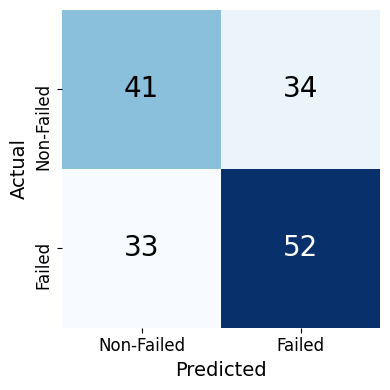

In [272]:
import matplotlib.pyplot as plt

# Dati
# Crea la matrice di confusione
confusion_matrix = [[tn, fp], [fn, tp]]

# Crea la figura
plt.figure(figsize=(4, 4))  # Imposta le dimensioni della figura

# Plot della matrice di confusione
plt.imshow(confusion_matrix, interpolation='nearest', cmap=plt.cm.Blues)

# Aggiungi annotazioni di testo per ogni cella con formattazione personalizzata
for i in range(2):
    for j in range(2):
        color = 'black' if confusion_matrix[i][j] < 50 else 'white'  # Colore adattivo per contrasto
        plt.text(j, i, str(confusion_matrix[i][j]), fontsize=20, color=color, ha='center', va='center')

# Aggiungi le etichette agli assi
tick_marks = [0, 1]
class_labels = ["Non-Failed", "Failed"]

plt.xticks(tick_marks, class_labels, fontsize=12)
plt.yticks(tick_marks, class_labels, fontsize=12, rotation=90)  # Rotazione verticale e font size

# Rimuovi i bordi della matrice di confusione
for spine in plt.gca().spines.values():
    spine.set_visible(False)

# Aggiungi titoli agli assi
plt.ylabel('Actual', fontsize=14)
plt.xlabel('Predicted', fontsize=14)

plt.tight_layout()  # Regola il layout per evitare che le etichette vengano tagliate

# Salva l'immagine nel percorso specificato
#filepath = '/content/drive/My Drive/Tesi_Corino/CM_OB3_NEW.png'
#plt.savefig(filepath)

plt.show()

## EXT TEST

In [207]:
len(y_test_pred)

160

In [273]:
from sklearn.metrics import confusion_matrix, balanced_accuracy_score, f1_score, recall_score, roc_auc_score



# Calcolo confusion matrix
cm_patient = confusion_matrix(y_ext_w, y_ext_pred)

# Calcolo metriche
bal_acc_patient = balanced_accuracy_score(y_ext_w, y_ext_pred)
f1_patient = f1_score(y_ext_w, y_ext_pred)
sensitivity_patient = recall_score(y_ext_w, y_ext_pred)  # recall = sensitivity
tn, fp, fn, tp = cm_patient.ravel()
specificity_patient = tn / (tn + fp)
auc_patient = roc_auc_score(y_ext_w, y_ext_prob)

print("Confusion Matrix (a livello paziente):")
print(cm_patient)
print(f"Balanced Accuracy: {bal_acc_patient:.3f}")
print(f"F1 Score: {f1_patient:.3f}")
print(f"Sensitivity: {sensitivity_patient:.3f}")
print(f"Specificity: {specificity_patient:.3f}")
print(f"AUC: {auc_patient:.3f}")

Confusion Matrix (a livello paziente):
[[126 189]
 [ 45 243]]
Balanced Accuracy: 0.622
F1 Score: 0.675
Sensitivity: 0.844
Specificity: 0.400
AUC: 0.637


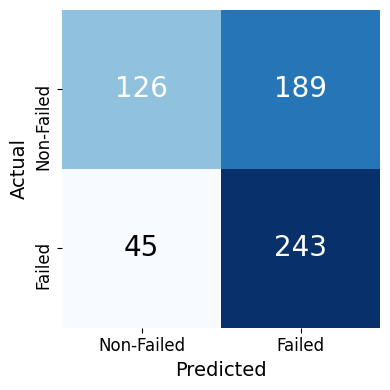

In [274]:
import matplotlib.pyplot as plt

# Dati
# Crea la matrice di confusione
confusion_matrix = [[tn, fp], [fn, tp]]

# Crea la figura
plt.figure(figsize=(4, 4))  # Imposta le dimensioni della figura

# Plot della matrice di confusione
plt.imshow(confusion_matrix, interpolation='nearest', cmap=plt.cm.Blues)

# Aggiungi annotazioni di testo per ogni cella con formattazione personalizzata
for i in range(2):
    for j in range(2):
        color = 'black' if confusion_matrix[i][j] < 50 else 'white'  # Colore adattivo per contrasto
        plt.text(j, i, str(confusion_matrix[i][j]), fontsize=20, color=color, ha='center', va='center')

# Aggiungi le etichette agli assi
tick_marks = [0, 1]
class_labels = ["Non-Failed", "Failed"]

plt.xticks(tick_marks, class_labels, fontsize=12)
plt.yticks(tick_marks, class_labels, fontsize=12, rotation=90)  # Rotazione verticale e font size

# Rimuovi i bordi della matrice di confusione
for spine in plt.gca().spines.values():
    spine.set_visible(False)

# Aggiungi titoli agli assi
plt.ylabel('Actual', fontsize=14)
plt.xlabel('Predicted', fontsize=14)

plt.tight_layout()  # Regola il layout per evitare che le etichette vengano tagliate

# Salva l'immagine nel percorso specificato
#filepath = '/content/drive/My Drive/Tesi_Corino/CM_OB3_NEW.png'
#plt.savefig(filepath)

plt.show()

### Bootstrapping - 100 boots and 95% CI
Applly for each model:
- Clinical model
- Comorbidity model 

In [138]:
import numpy as np
import pandas as pd

from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    roc_auc_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix
)

# =========================================================
# 1) Bootstrap row-level indices
# =========================================================
def generate_row_bootstrap_indices_from_arrays(
    y,
    n_boot=100,
    random_state=42,
    replace=True,
    sample_size=None,
    require_both_classes=False,
    max_tries=50000
):
    """
    Bootstrap row-level su array/serie y.
    Campiona indici delle righe del validation/test set.
    """
    rng = np.random.default_rng(random_state)
    n = len(y)

    if sample_size is None:
        sample_size = n

    idx_all = np.arange(n)

    boot_index_list = []
    tries = 0

    y = np.asarray(y)

    while len(boot_index_list) < n_boot and tries < max_tries:
        tries += 1
        idx = rng.choice(idx_all, size=sample_size, replace=replace)

        if require_both_classes:
            yb = y[idx]
            if np.unique(yb).size < 2:
                continue

        boot_index_list.append(idx)

    if len(boot_index_list) < n_boot:
        print(f"Only created {len(boot_index_list)} bootstraps (requested {n_boot}).")

    return boot_index_list


# =========================================================
# 2) Metriche da y_true, y_prob, y_pred
# =========================================================
def compute_metrics_from_predictions(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    # confusion matrix robusta
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    # AUC definita solo se entrambe le classi sono presenti
    if np.unique(y_true).size < 2:
        auc = np.nan
    else:
        auc = roc_auc_score(y_true, y_prob)

    bal_acc = balanced_accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    return {
        "AUC": auc,
        "Balanced_Accuracy": bal_acc,
        "F1_Score": f1,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn
    }


# =========================================================
# 3) Bootstrap CI su predizioni già ottenute
# =========================================================
def bootstrap_ci_metrics_from_predictions(
    y_true,
    y_prob,
    boot_index_list,
    threshold=0.5,
    ci=0.95,
    estimate_mode="boot_mean"
):
    """
    Stessa logica del tuo bootstrap sui checkup:
    - modello fisso
    - si ricampionano le righe del validation/test set
    - si ricalcolano le metriche
    """
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    # point estimate sul dataset intero
    point_metrics = compute_metrics_from_predictions(y_true, y_prob, threshold=threshold)

    # bootstrap metrics
    boot_rows = []
    for b, idx in enumerate(boot_index_list):
        yt_b = y_true[idx]
        yp_b = y_prob[idx]

        # salta bootstrap degeneri
        if np.unique(yt_b).size < 2:
            continue

        m = compute_metrics_from_predictions(yt_b, yp_b, threshold=threshold)
        m["bootstrap_id"] = b
        boot_rows.append(m)

    boot_df = pd.DataFrame(boot_rows)

    alpha = 1 - ci
    low_q = alpha / 2
    high_q = 1 - alpha / 2

    metric_cols = ["AUC", "Balanced_Accuracy", "F1_Score", "Sensitivity", "Specificity"]

    summary_rows = []
    for metric in metric_cols:
        vals = boot_df[metric].dropna().values

        if len(vals) == 0:
            boot_mean = np.nan
            boot_sd = np.nan
            ci_low = np.nan
            ci_high = np.nan
            reported_est = np.nan
            n_boot_used = 0
        else:
            boot_mean = np.mean(vals)
            boot_sd = np.std(vals, ddof=1)
            ci_low = np.quantile(vals, low_q)
            ci_high = np.quantile(vals, high_q)
            reported_est = boot_mean if estimate_mode == "boot_mean" else point_metrics[metric]
            n_boot_used = len(vals)

        summary_rows.append({
            "Metric": metric,
            "Estimate": point_metrics[metric],
            "Boot_mean": boot_mean,
            "Boot_sd": boot_sd,
            "CI_low": ci_low,
            "CI_high": ci_high,
            "n_boot_used": n_boot_used,
            "Reported": (
                f"{reported_est:.3f} ({ci_low:.3f}–{ci_high:.3f})"
                if pd.notnull(reported_est) and pd.notnull(ci_low) and pd.notnull(ci_high)
                else "NA"
            )
        })

    summary_df = pd.DataFrame(summary_rows)

    point_metrics_df = pd.DataFrame([point_metrics])

    return summary_df, point_metrics_df, boot_df


# =========================================================
# 4) Fit una volta ogni classificatore + bootstrap su validation
# =========================================================
def evaluate_classifiers_with_bootstrap(
    X_train,
    y_train,
    X_val,
    y_val,
    classifiers,
    n_boot=100,
    threshold=0.5,
    random_state=42,
    smote_k_neighbors=2,
    ci=0.95,
    estimate_mode="boot_mean"
):
    """
    classifiers = list of tuples:
        [('XGB', xgb_classif), ('RF', rf_classif), ...]
    dove classifier_func(trainX, trainY, valX, valY) restituisce:
        bal_acc, f1, sensitivity, specificity, auc, _, _, _, _, model
    """

    # SMOTE sul training
    sm = SMOTE(sampling_strategy='minority', k_neighbors=smote_k_neighbors, random_state=random_state)
    xtrain_res, ytrain_res = sm.fit_resample(X_train, y_train)

    # bootstrap indices sul validation set
    boot_index_list = generate_row_bootstrap_indices_from_arrays(
        y=y_val,
        n_boot=n_boot,
        random_state=random_state,
        replace=True,
        sample_size=len(y_val),
        require_both_classes=True
    )

    all_summaries = []
    all_points = []
    all_boots = []
    fitted_models = {}

    for classifier_name, classifier_func in classifiers:
        print(f"Processing {classifier_name}...")

        # train + evaluation standard tramite tua funzione
        bal_acc_val, f1_val, sens_val, spec_val, auc_val, _, _, _, _, model = classifier_func(
            xtrain_res, ytrain_res, X_val, y_val
        )

        # predicted probabilities del modello sul validation set
        y_prob_val = model.predict_proba(X_val)[:, 1]

        # bootstrap CI
        summary_df, point_df, boot_df = bootstrap_ci_metrics_from_predictions(
            y_true=y_val,
            y_prob=y_prob_val,
            boot_index_list=boot_index_list,
            threshold=threshold,
            ci=ci,
            estimate_mode=estimate_mode
        )

        summary_df["Classifier"] = classifier_name
        point_df["Classifier"] = classifier_name
        boot_df["Classifier"] = classifier_name

        # opzionale: sovrascrivo i point estimate con quelli ritornati dalla tua funzione
        point_df["AUC"] = auc_val
        point_df["Balanced_Accuracy"] = bal_acc_val
        point_df["F1_Score"] = f1_val
        point_df["Sensitivity"] = sens_val
        point_df["Specificity"] = spec_val

        all_summaries.append(summary_df)
        all_points.append(point_df)
        all_boots.append(boot_df)

        fitted_models[classifier_name] = model

    summary_all = pd.concat(all_summaries, ignore_index=True)
    point_all = pd.concat(all_points, ignore_index=True)
    boot_all = pd.concat(all_boots, ignore_index=True)

    return summary_all, point_all, boot_all, fitted_models


In [ ]:
classifiers = [
    ('XGB', xgb_classif),
    ('RF', rf_classif),
    ('MLP', mlp_classif),
    ('ADA', ada_classif),
    ('LR', lr_classif)
]

summary_all_val, point_all_val, boot_all_val, fitted_models_val = evaluate_classifiers_with_bootstrap(
    X_train=X_train_wide,
    y_train=y_train_w,
    X_val=X_val_wide,
    y_val=y_val_w,
    classifiers=classifiers,
    n_boot=100,
    threshold=0.5,
    random_state=42,
    smote_k_neighbors=2,
    ci=0.95,
    estimate_mode="boot_mean"   # media dei bootstrap come nel tuo codice
)

Processing XGB...
Processing RF...
Processing ADA...


In [ ]:
# 6) TABELLE FINALI
# =========================================================

# point estimates compatti
point_table = point_all_val[[
    "Classifier", "AUC", "Balanced_Accuracy", "F1_Score", "Sensitivity", "Specificity"
]].copy()

print("\nPOINT ESTIMATES")
print(point_table)

# tabella summary con CI
summary_table = summary_all_val[[
    "Classifier", "Metric", "Estimate", "Boot_mean", "Boot_sd", "CI_low", "CI_high", "n_boot_used", "Reported"
]].copy()

print("\nBOOTSTRAP SUMMARY")
print(summary_table)

# se vuoi una pivot finale più leggibile
summary_pivot = summary_all_val.pivot(index="Classifier", columns="Metric", values="Reported")
print("\nREPORTED TABLE")
summary_pivot

In [ ]:
summary_table